<a href="https://colab.research.google.com/github/maiaragoudapatil-art/Heart-Disease-Prediction-Using-Machine-Learning/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Heart Disease Prediction

Heart disease is one of the leading causes of death worldwide. Early detection of heart disease can help doctors provide timely treatment and prevent serious health complications.
The goal of this project is to build a machine learning model that can predict whether a patient has heart disease based on clinical measurements such as age, cholesterol level, blood pressure, and heart rate.
Using machine learning techniques, the system analyzes medical data and learns patterns associated with heart disease, allowing it to predict the likelihood of disease in new patients


The objective of this project is to develop a classification model that predicts whether a patient has heart disease using clinical and physiological attributes.

In [1]:
!pip install xgboost shap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import shap

In [3]:
df = pd.read_csv('/content/heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Check dataset info:

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Check missing values:

In [5]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Exploratory Data Analysis (EDA)
Target Distribution

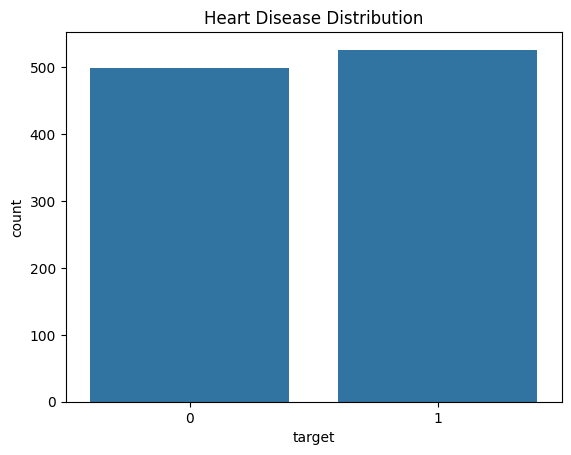

In [6]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

Distribution Plots

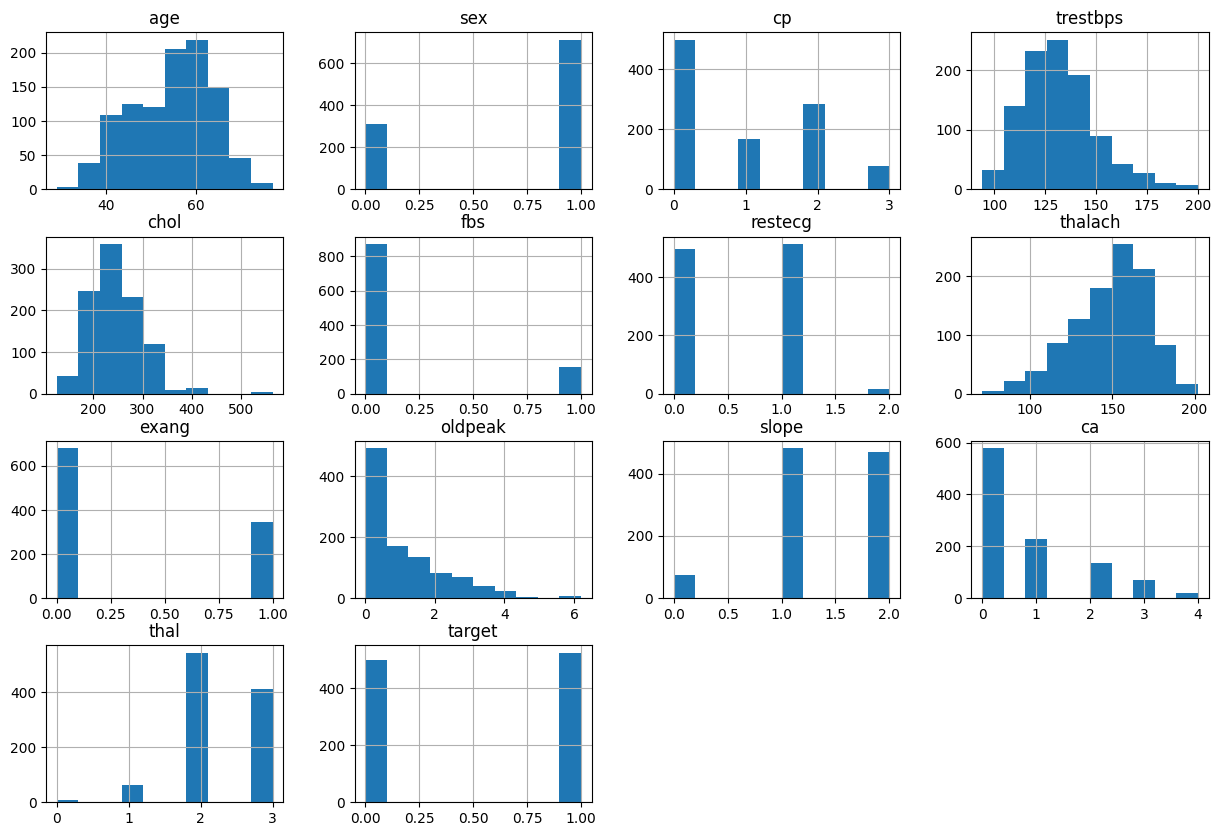

In [7]:
df.hist(figsize=(15,10))
plt.show()

Correlation Heatmap  This helps identify important features influencing heart disease.

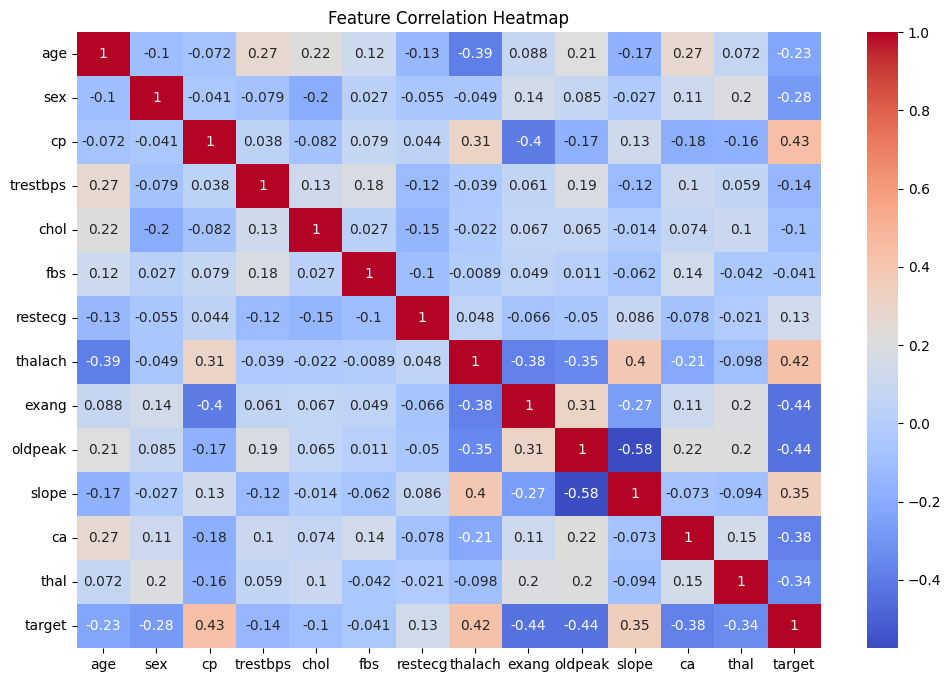

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

Feature & Target Split

In [9]:
X = df.drop('target', axis=1)
y = df['target']

Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled
X_test_scaled

array([[ 0.83316836, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.1492222 , -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -3.85673683],
       [ 0.06908682,  0.65465367, -0.91672034, ..., -0.64007851,
         0.24025219,  1.11057867],
       ...,
       [-1.13161275,  0.65465367,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [ 0.72401385,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219,  1.11057867],
       [ 0.39655033,  0.65465367,  1.008275  , ..., -0.64007851,
         0.24025219,  1.11057867]])

In [13]:
scaler

StandardScaler()

Logistic Regression Model

In [14]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



Random Forest Model

In [15]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



XGBoost Model


In [16]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:05:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC Evaluation

In [17]:
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Logistic Regression ROC-AUC: 0.8787359604035789
Random Forest ROC-AUC: 1.0
XGBoost ROC-AUC: 0.9894346087949742


ROC Curve Visualization

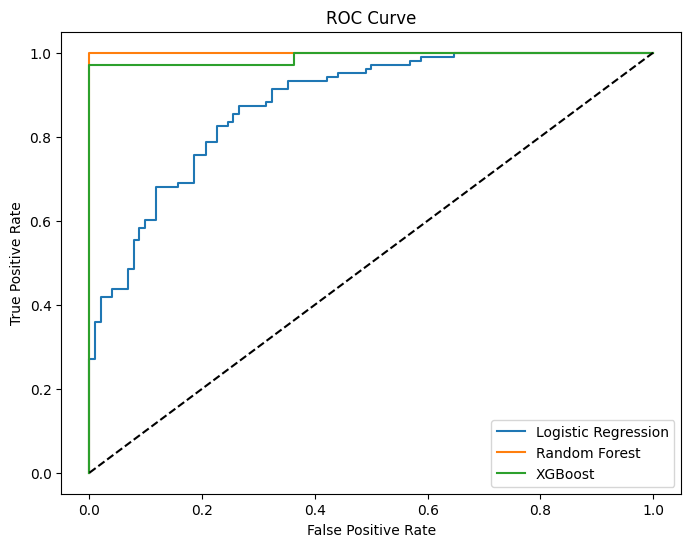

In [18]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Precision-Recall Curve

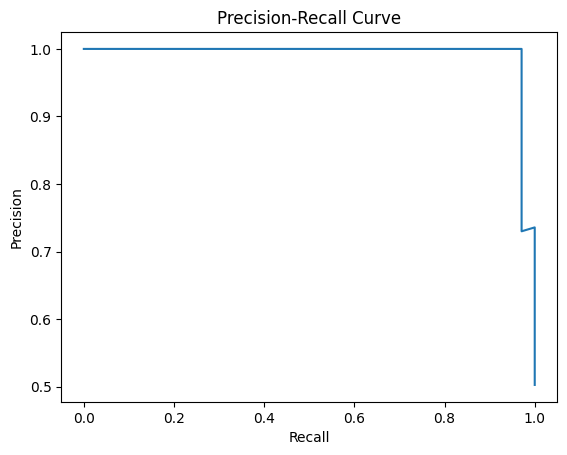

In [19]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

SHAP Feature Importance

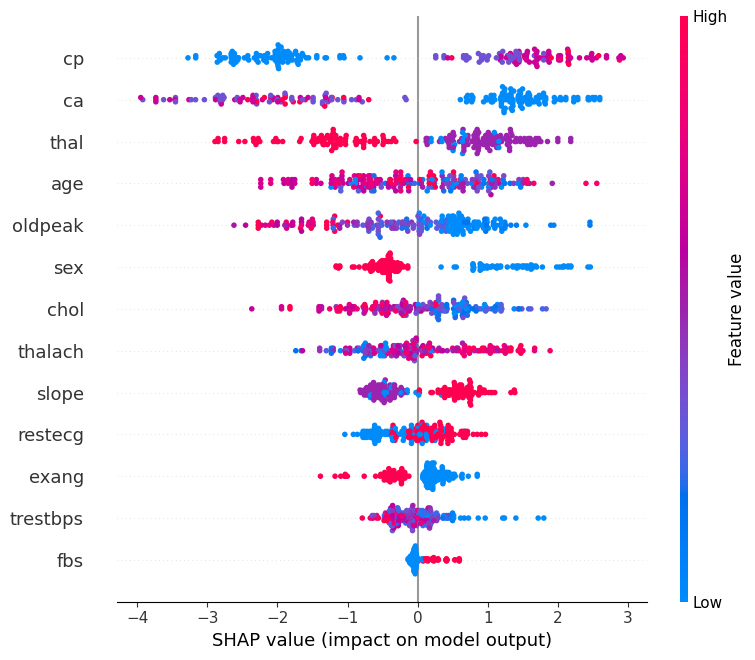

In [20]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)